<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/depmap/02_dagilim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tabloyu tanımak: skorların dağılımı

4.1'de tabloyu kurduk, bu defterde ona ilk sorularımızı soruyoruz. Üç soru: skorlar genel olarak nasıl dağılıyor, hangi genler her hatta ölümcül, ve hangileri hiçbir hatta bir şey yapmıyor? Bu ayrım projenin geri kalanının zeminini kuruyor — çünkü iyi bir ilaç hedefi ne birincisidir ne ikincisi.

## 1. Veriyi okumak

Veri artık 4.1'de yayımladığımız Zenodo kaydından geliyor. `urllib.request.urlretrieve` dosyayı indirir, `pd.read_csv(..., index_col=0)` ilk sütunu (ModelID) satır adı yapar. Skor dosyası 40 MB, indirme birkaç saniye sürer.

Not: Zenodo dosya adlarında boşluk varsa URL'de `%20` olarak yazılır; aşağıdaki adresler kaydınızdaki adlarla birebir eşleşmeli.

In [1]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

KOK = 'https://zenodo.org/records/22759375/files'
urllib.request.urlretrieve(f'{KOK}/depmap_ders_skorlar%20(1).csv?download=1', 'skorlar.csv')
urllib.request.urlretrieve(f'{KOK}/depmap_ders_kunye%20(1).csv?download=1', 'kunye.csv')

skor = pd.read_csv('skorlar.csv', index_col=0)
kunye = pd.read_csv('kunye.csv', index_col=0)
print('skor:', skor.shape, '| künye:', kunye.shape)

skor: (1208, 5000) | künye: (1208, 3)


## 2. Bütün skorların dağılımı

İlk resim en temel olanı: 1.208 hat × 5.000 genin bütün skorlarını tek histogramda görmek. `values.ravel()` matrisi tek boyutlu diziye açar, `dropna` boşları atar.

Dikkat edilecek iki nokta: dağılımın tepesi nerede, ve sol tarafta ayrı bir kabartı var mı? Chronos ölçeğinde sıfır "hiçbir şey olmadı" demekti; tepe oradaysa, taranan genlerin çoğu o hücre için vazgeçilebilir demektir. Kesikli çizgiler iki referansı gösteriyor: 0 ve −1.

toplam ölçüm: 6.0 milyon
medyan: -0.257 | %1 dilim: -2.75 | %99 dilim: 0.33
skoru -0.5 altında olan ölçüm oranı: %34.1


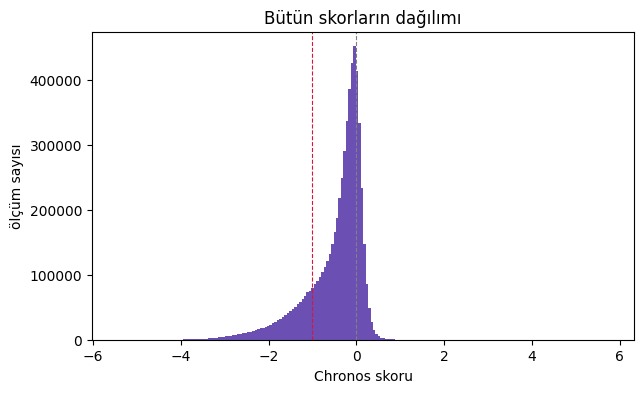

In [2]:
hepsi = skor.values.ravel()
hepsi = hepsi[~np.isnan(hepsi)]

print('toplam ölçüm: %.1f milyon' % (len(hepsi) / 1e6))
print('medyan: %.3f | %%1 dilim: %.2f | %%99 dilim: %.2f' % (
    np.median(hepsi), np.percentile(hepsi, 1), np.percentile(hepsi, 99)))
print('skoru -0.5 altında olan ölçüm oranı: %%%.1f' % (100 * (hepsi < -0.5).mean()))

plt.figure(figsize=(7, 4))
plt.hist(hepsi, bins=200, color='#6B4FB3')
plt.axvline(0, ls='--', lw=0.8, c='gray')
plt.axvline(-1, ls='--', lw=0.8, c='crimson')
plt.xlabel('Chronos skoru'); plt.ylabel('ölçüm sayısı')
plt.title('Bütün skorların dağılımı');

## 3. Gen bazında özet

Şimdi soruyu gene çeviriyoruz: her gen için bütün hatlardaki medyanı ve standart sapmayı hesaplıyoruz. İki sayı iki ayrı şey söyler — medyan "tipik olarak ne kadar ölümcül", standart sapma "hatlar arasında ne kadar değişiyor".

Bu ikisinin birlikte çizimi bu projenin temel haritasıdır ve 4.4'te geri döneceğiz. Şimdilik sadece üç bölgeyi tanıyın: sol alt (her hatta ölümcül, az değişken), sağ alt (etkisiz, az değişken), ve orta-üst (bazı hatlarda ölümcül, bazılarında değil — seçici bağımlılıklar).

         medyan       std
count  5000.000  5000.000
mean     -0.467     0.248
std       0.601     0.106
min      -4.166     0.083
25%      -0.678     0.176
50%      -0.238     0.222
75%      -0.059     0.308
max       0.341     0.951


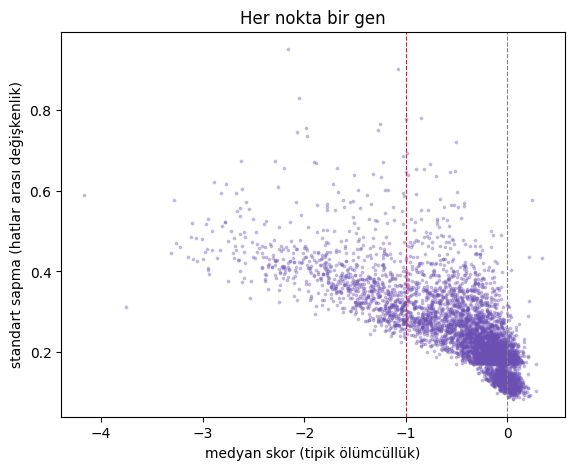

In [3]:
ozet = pd.DataFrame({'medyan': skor.median(), 'std': skor.std()})
ozet['sembol'] = [c.split(' ')[0] for c in ozet.index]
print(ozet[['sembol', 'medyan', 'std']].describe().round(3))

plt.figure(figsize=(6.5, 5))
plt.scatter(ozet.medyan, ozet['std'], s=3, alpha=0.3, color='#6B4FB3')
plt.axvline(0, ls='--', lw=0.8, c='gray')
plt.axvline(-1, ls='--', lw=0.8, c='crimson')
plt.xlabel('medyan skor (tipik ölümcüllük)'); plt.ylabel('standart sapma (hatlar arası değişkenlik)')
plt.title('Her nokta bir gen');

## 4. İki uç: ortak esansiyeller ve etkisizler

Tanımları sayıyla kuruyoruz. **Ortak esansiyel** dediğimiz genler, hatların hemen hepsinde belirgin ölümcül olanlardır; ölçüt olarak "hatların en az %90'ında skoru −0,5'in altında" kullanıyoruz. **Etkisiz** genler ise hiçbir hatta iz bırakmayanlar: hiçbir hatta −0,5'in altına inmeyenler.

Eşik olarak −0,5 seçmemizin nedeni pratiktir: sıfır çevresindeki gürültüden yeterince uzak, ama −1 kadar katı değil. Eşik bir karardır, doğa yasası değil — raporda değeriyle yazılır.

In [4]:
esik = -0.5
oran = (skor < esik).mean()          # her gen için: kaç hatta eşiğin altında
ortak_esansiyel = oran[oran >= 0.90].index
etkisiz = oran[oran == 0].index

print('ortak esansiyel gen:', len(ortak_esansiyel))
print('hiçbir hatta etkisi olmayan gen:', len(etkisiz))
print('ikisi de değil (aradakiler):', skor.shape[1] - len(ortak_esansiyel) - len(etkisiz))

print('\nen ölümcül 10 ortak esansiyel:')
print(ozet.loc[ortak_esansiyel].sort_values('medyan').head(10)[['sembol', 'medyan', 'std']].to_string())

ortak esansiyel gen: 961
hiçbir hatta etkisi olmayan gen: 287
ikisi de değil (aradakiler): 3752

en ölümcül 10 ortak esansiyel:
               sembol  medyan       std
RAN (5901)        RAN -4.1655  0.588927
RPL17 (6139)    RPL17 -3.7535  0.311602
RPS8 (6202)      RPS8 -3.3105  0.445720
RRM1 (6240)      RRM1 -3.2785  0.575732
SNRPF (6636)    SNRPF -3.2630  0.470529
SNRPA1 (6627)  SNRPA1 -3.2200  0.460395
PSMA6 (5687)    PSMA6 -3.1475  0.435281
RPL12 (6136)    RPL12 -3.1155  0.485640
PCNA (5111)      PCNA -3.1090  0.519691
PSMB3 (5691)    PSMB3 -3.0970  0.430362


## 5. Üç genin profili yan yana

Son olarak üç geni tek resimde karşılaştırıyoruz: bir ortak esansiyel, bir etkisiz ve KRAS. Her histogram bir genin 1.208 hattaki skor dağılımı. KRAS'ın dağılımının şekline dikkat edin — 4.1'de medyanının −0,52 olduğunu görmüştük; dağılım o sayının neyi sakladığını gösterecek.

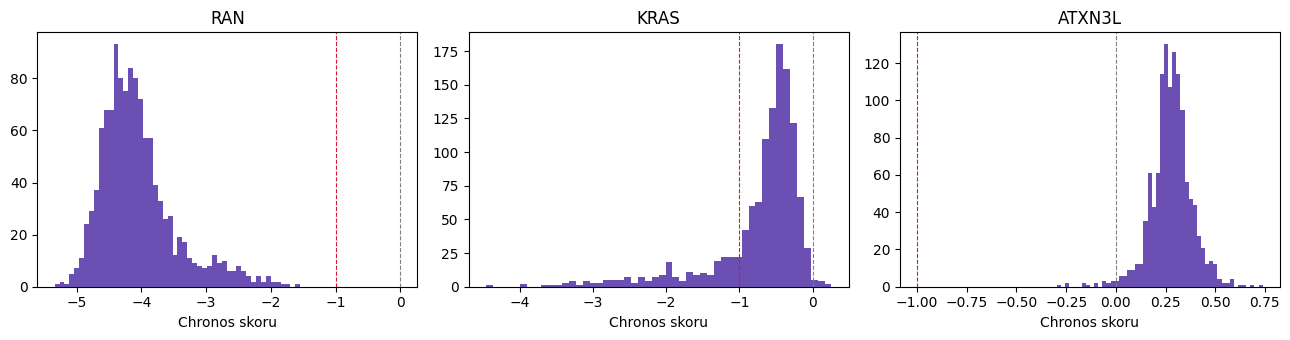

In [5]:
def sutun(sembol):
    e = [c for c in skor.columns if c.split(' ')[0] == sembol]
    return e[0] if e else None

secim = [ozet.loc[ortak_esansiyel].medyan.idxmin(), sutun('KRAS'), ozet.loc[etkisiz].medyan.idxmax()]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c in zip(axes, secim):
    if c is None: continue
    ax.hist(skor[c].dropna(), bins=50, color='#6B4FB3')
    ax.axvline(0, ls='--', lw=0.8, c='gray'); ax.axvline(-1, ls='--', lw=0.8, c='crimson')
    ax.set_title(c.split(' ')[0]); ax.set_xlabel('Chronos skoru')
plt.tight_layout();

## Kendin dene

Üç görev. Birincisi: bütün skorların medyanını, %1 ve %99 dilimlerini ve −0,5 altındaki ölçüm oranını not edin; tek cümleyle yazın — bu dağılım, taranan genlerin çoğu hakkında ne söylüyor? İkincisi: ortak esansiyel ve etkisiz gen sayılarını yazın, en ölümcül on genin isimlerine bakın ve tek cümleyle söyleyin: bu genler hangi hücresel süreçlere ait ve neden ilaç hedefi olarak kötü adaylardır? Üçüncüsü: üç histogramı karşılaştırın ve KRAS'ınkinin diğer ikisinden farkını tek cümleyle tarif edin — bu fark, bir sonraki rehberin konusunu kuruyor.